## Chapter 2 — Data and Sampling Distributions

**Buku:** *Practical Statistics for Data Scientists* (O'Reilly)   

### Tujuan
Chapter ini membahas bagaimana data diperoleh melalui sampling, bagaimana bias dapat muncul, bagaimana distribusi sampling digunakan untuk memahami ketidakpastian suatu statistik, serta bagaimana bootstrap, confidence interval, dan berbagai probability distributions digunakan dalam statistical inference.



# 1. Overview Chapter 2

Chapter 2 berfokus pada **Data and Sampling Distributions**.

Materi utama:

1. Random Sampling dan Sample Bias
2. Selection Bias
3. Regression to the Mean
4. Sampling Distribution of a Statistic
5. Central Limit Theorem
6. Standard Error
7. Bootstrap
8. Confidence Intervals
9. Normal Distribution
10. Standard Normal dan QQ-Plot
11. Long-Tailed Distributions
12. Student's t-Distribution
13. Binomial Distribution
14. Chi-Square Distribution
15. F-Distribution
16. Poisson dan Related Distributions
17. Exponential Distribution
18. Weibull Distribution

Gagasan sentral chapter adalah membedakan **distribusi data** dengan **distribusi sampling dari suatu statistik**. Distribusi sampling membantu kita memahami seberapa bervariasi suatu estimasi ketika sampel berbeda diambil dari populasi.

# 2. Random Sampling dan Sample Bias

**Population** adalah keseluruhan kelompok yang ingin dipelajari, sedangkan **sample** adalah subset dari population.

Random sampling berarti setiap anggota population memiliki kesempatan untuk dipilih secara acak. Tujuannya adalah memperoleh sample yang cukup representatif sehingga statistik sample dapat digunakan untuk mempelajari population.

### Bias

Bias terjadi ketika proses pengukuran atau pengambilan sample menghasilkan kesalahan yang sistematis. Berbeda dengan random error, bias tidak hilang hanya dengan menambah jumlah observasi.

Contoh bentuk bias yang dibahas chapter:

- sample bias,
- self-selection bias,
- selection bias,
- data snooping,
- cherry-picking,
- stopping an experiment ketika hasil terlihat menarik.

Chapter menggunakan kegagalan Literary Digest poll sebagai ilustrasi historis bahwa sample besar tetap dapat menghasilkan kesimpulan yang salah jika sample tidak representatif. fileciteturn1file0L3-L8

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.utils import resample

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(42)

## 2.1 Simulasi Random Sampling vs Biased Sampling

Contoh berikut bukan data Literary Digest, melainkan simulasi sederhana untuk memperlihatkan ide yang sama: random sampling cenderung menghasilkan estimasi yang lebih dekat dengan population, sedangkan sampling yang sistematis/selektif dapat menghasilkan estimasi yang bias.

In [2]:
population = pd.DataFrame({
    "group": np.repeat(["A", "B"], [7000, 3000])
})

population_rate = (population["group"] == "B").mean()

# Random sample
random_sample = population.sample(1000, random_state=42)

# Biased sample: mengambil proporsi B yang jauh lebih besar
biased_sample = pd.concat([
    population[population["group"] == "A"].sample(400, random_state=42),
    population[population["group"] == "B"].sample(600, random_state=42)
])

print(f"Population proportion of B : {population_rate:.3f}")
print(f"Random sample proportion B : {(random_sample['group'] == 'B').mean():.3f}")
print(f"Biased sample proportion B : {(biased_sample['group'] == 'B').mean():.3f}")

Population proportion of B : 0.300
Random sample proportion B : 0.315
Biased sample proportion B : 0.600


### Interpretasi

Population sebenarnya memiliki proporsi kelompok B sebesar 30%. Random sample berukuran 1.000 dapat menghasilkan angka yang dekat dengan 30%, walaupun tidak harus persis sama. Sebaliknya, biased sample yang sengaja mengambil lebih banyak anggota kelompok B menghasilkan estimasi yang sistematis lebih tinggi.

**Inti:** ukuran sample yang besar tidak otomatis menghilangkan bias. Cara data dipilih tetap sangat penting.

# 3. Selection Bias dan Regression to the Mean

**Selection bias** terjadi ketika observasi yang masuk ke analisis dipilih dengan cara yang membuatnya berbeda secara sistematis dari population.

Chapter juga membahas **regression to the mean**. Ketika kita memilih observasi karena memiliki nilai yang ekstrem, pengukuran berikutnya cenderung bergerak lebih dekat ke nilai rata-rata. Ini bukan berarti ada gaya yang "menarik" nilai kembali, tetapi merupakan konsekuensi statistik dari adanya variasi dan korelasi yang tidak sempurna.

Contoh sederhana dapat dibuat dengan dua pengukuran yang berkorelasi.

In [3]:
n = 5000
x = rng.normal(0, 1, n)
noise = rng.normal(0, 0.8, n)
y = 0.65 * x + noise

# Pilih observasi dengan nilai x paling ekstrem
threshold = np.quantile(x, 0.90)
selected = x >= threshold

print("Mean x seluruh data      :", x.mean())
print("Mean y seluruh data      :", y.mean())
print("Mean x pada selected     :", x[selected].mean())
print("Mean y pada selected     :", y[selected].mean())

Mean x seluruh data      : -0.019877039492199437
Mean y seluruh data      : -0.013418244738588726
Mean x pada selected     : 1.7453172733937945
Mean y pada selected     : 1.0849374633271005


### Interpretasi

Observasi dipilih berdasarkan nilai `x` yang sangat tinggi. Ketika nilai `y` yang berhubungan dengan `x` dilihat pada kelompok tersebut, nilainya tidak harus sama ekstremnya dengan `x`. Hal tersebut mengilustrasikan regression to the mean.

# 4. Dataset: Loan Applicant Income

Untuk bagian sampling distribution dan bootstrap, Chapter menggunakan data pendapatan tahunan pemohon pinjaman (`loans_income`).

Data ini memiliki distribusi yang cenderung right-skewed, sehingga cocok untuk memperlihatkan perbedaan antara distribusi data dan distribusi sample mean.

In [4]:
DATA_BASE = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"

loans_income = pd.read_csv(
    DATA_BASE + "loans_income.csv"
).squeeze("columns")

print("Jumlah observasi:", len(loans_income))
loans_income.describe()

Jumlah observasi: 50000


,x
count,50000.00000
mean,68760.51844
std,32872.03537
min,4000.00000
25%,45000.00000
50%,62000.00000
75%,85000.00000
max,199000.00000


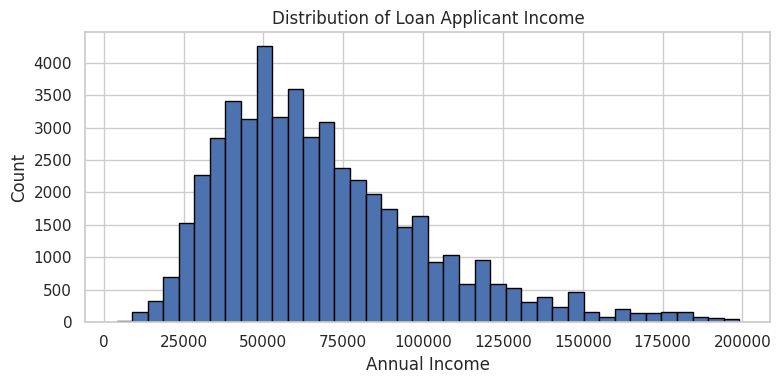

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(loans_income, bins=40, edgecolor="black")
ax.set_xlabel("Annual Income")
ax.set_ylabel("Count")
ax.set_title("Distribution of Loan Applicant Income")
plt.tight_layout()
plt.show()

# 5. Sampling Distribution of a Statistic

**Data distribution** adalah distribusi nilai individual dalam dataset.

**Sampling distribution** adalah distribusi suatu statistik, misalnya mean, yang diperoleh dari banyak sample dengan ukuran tertentu.

Perbedaan ini sangat penting:

```text
Population
   ↓ sampling
Sample
   ↓ calculate statistic
Sample statistic
   ↓ repeat sampling
Sampling distribution
```

Distribusi sample mean biasanya lebih teratur dan lebih sempit daripada distribusi data individual. Ketika ukuran sample meningkat, variasi sample mean semakin kecil.

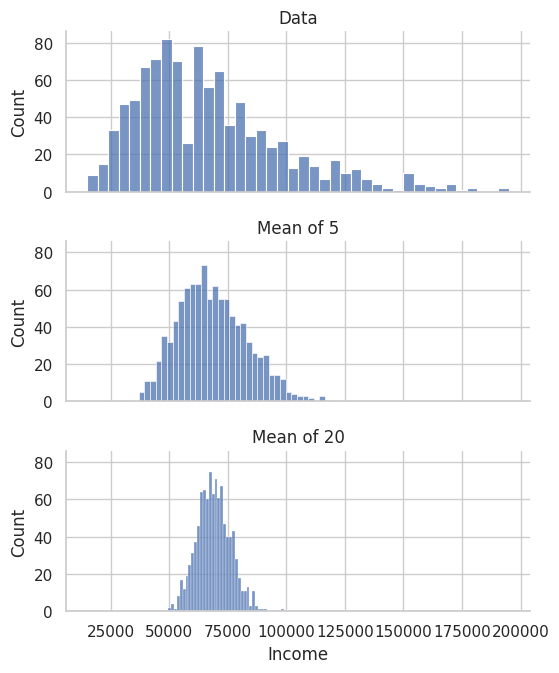

In [6]:
# Sample 1,000 individual observations
sample_data = pd.DataFrame({
    "income": loans_income.sample(1000, random_state=42),
    "type": "Data"
})

# 1,000 sample means, each based on n=5
sample_mean_5 = pd.DataFrame({
    "income": [
        loans_income.sample(5, random_state=1000 + i).mean()
        for i in range(1000)
    ],
    "type": "Mean of 5"
})

# 1,000 sample means, each based on n=20
sample_mean_20 = pd.DataFrame({
    "income": [
        loans_income.sample(20, random_state=2000 + i).mean()
        for i in range(1000)
    ],
    "type": "Mean of 20"
})

sampling_results = pd.concat(
    [sample_data, sample_mean_5, sample_mean_20],
    ignore_index=True
)

g = sns.FacetGrid(
    sampling_results,
    row="type",
    height=2.3,
    aspect=2.5
)
g.map_dataframe(
    sns.histplot,
    x="income",
    bins=40
)
g.set_axis_labels("Income", "Count")
g.set_titles("{row_name}")
plt.show()

### Interpretasi

Tiga distribusi menunjukkan:

- Data individual mempunyai penyebaran yang relatif lebar dan skewed.
- Distribusi mean dari sample berukuran 5 lebih sempit.
- Distribusi mean dari sample berukuran 20 lebih sempit dan lebih menyerupai bentuk normal.

Hal ini menjadi dasar untuk memahami **Central Limit Theorem** dan **standard error**.

# 6. Central Limit Theorem

Central Limit Theorem (CLT) menyatakan bahwa distribusi sample mean akan semakin mendekati distribusi normal ketika ukuran sample cukup besar, meskipun distribusi population tidak normal.

Implikasinya sangat penting untuk statistical inference karena memungkinkan pendekatan normal/t-distribution digunakan untuk mempelajari distribusi suatu statistik.

CLT tidak berarti bahwa data mentah harus normal. Yang menjadi lebih mendekati normal adalah **distribusi sampling dari statistik**, dengan kondisi dan ukuran sample yang sesuai.

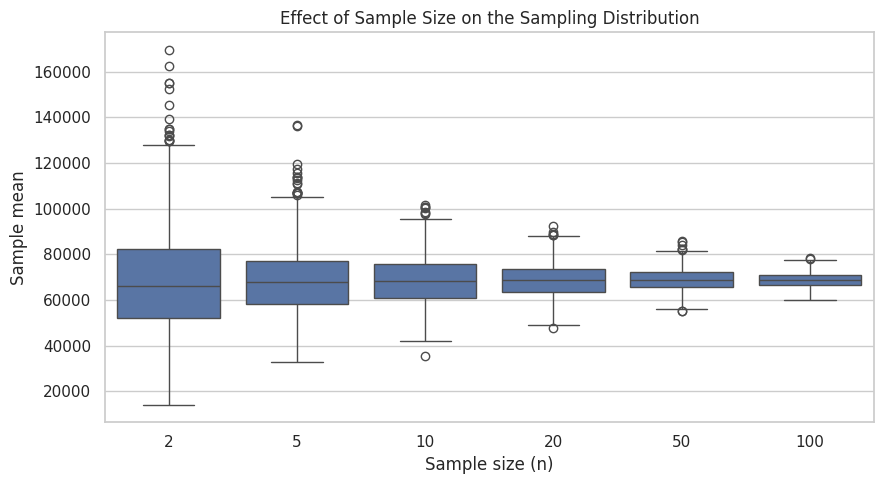

In [7]:
sample_sizes = [2, 5, 10, 20, 50, 100]
records = []

for n in sample_sizes:
    means = [
        loans_income.sample(n, random_state=10000 + i).mean()
        for i in range(1000)
    ]
    records.extend(
        {"n": n, "mean": m}
        for m in means
    )

clt_results = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=clt_results, x="n", y="mean", ax=ax)
ax.set_xlabel("Sample size (n)")
ax.set_ylabel("Sample mean")
ax.set_title("Effect of Sample Size on the Sampling Distribution")
plt.tight_layout()
plt.show()

# 7. Standard Error

Standard error mengukur variabilitas suatu sample statistic dari satu sample ke sample lain.

Untuk sample mean:

\[
SE = \frac{s}{\sqrt{n}}
\]

dengan:

- \(s\) = sample standard deviation,
- \(n\) = sample size.

Ketika \(n\) meningkat, standard error menurun. Hubungan ini mengikuti square-root rule: untuk mengurangi standard error menjadi sekitar setengahnya, ukuran sample perlu diperbesar sekitar empat kali.

**Standard deviation ≠ standard error.**

- Standard deviation → penyebaran nilai individual.
- Standard error → penyebaran sample statistic.

In [8]:
s = loans_income.std()
se_values = pd.DataFrame({
    "n": sample_sizes,
    "theoretical_SE": [s / np.sqrt(n) for n in sample_sizes]
})

se_values

,n,theoretical_SE
0,2,23244.039121
1,5,14700.821129
2,10,10395.050309
3,20,7350.410565
4,50,4648.807824
5,100,3287.203537


# 8. Bootstrap

Bootstrap adalah metode resampling dengan replacement dari observed sample.

Tujuannya adalah memperkirakan sampling distribution suatu statistic ketika kita tidak memiliki akses ke population yang sebenarnya.

Algoritma:

1. Ambil sample berukuran sama dengan sample asli.
2. Sampling dilakukan **with replacement**.
3. Hitung statistic.
4. Ulangi berkali-kali.
5. Gunakan distribusi statistic hasil resampling untuk mengestimasi variability dan confidence interval.

Bootstrap **tidak menciptakan data baru** dan tidak memperbaiki sample size yang terlalu kecil. Ia menggunakan informasi pada sample yang tersedia untuk memperkirakan bagaimana estimasi dapat bervariasi.

In [9]:
# Ambil sample awal berukuran 20
sample_20 = loans_income.sample(20, random_state=42)

bootstrap_means = np.array([
    sample_20.sample(
        n=len(sample_20),
        replace=True,
        random_state=5000 + i
    ).mean()
    for i in range(5000)
])

print("Original sample mean :", sample_20.mean())
print("Bootstrap mean       :", bootstrap_means.mean())
print("Bootstrap std. error :", bootstrap_means.std(ddof=1))

Original sample mean : 73691.25
Bootstrap mean       : 73689.59627
Bootstrap std. error : 7866.245545916954


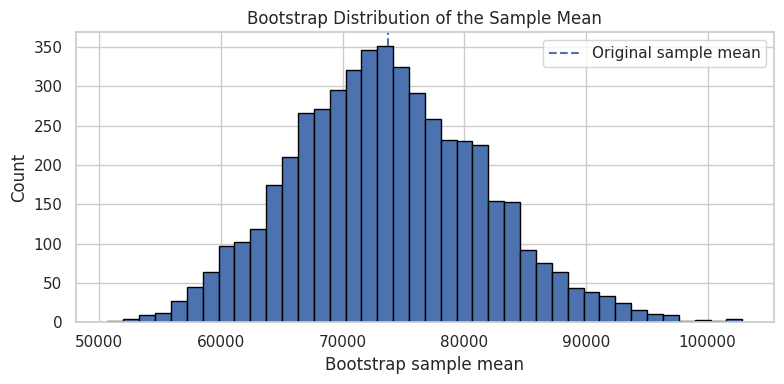

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(bootstrap_means, bins=40, edgecolor="black")
ax.axvline(sample_20.mean(), linestyle="--", label="Original sample mean")
ax.set_xlabel("Bootstrap sample mean")
ax.set_ylabel("Count")
ax.set_title("Bootstrap Distribution of the Sample Mean")
ax.legend()
plt.tight_layout()
plt.show()

# 9. Confidence Interval

Confidence interval memberikan rentang nilai yang digunakan untuk menggambarkan ketidakpastian suatu estimasi.

Dengan bootstrap percentile interval, misalnya confidence level 90%, kita mengambil batas percentile 5% dan 95% dari bootstrap distribution.

Penting untuk tidak menginterpretasikan confidence interval sebagai "probabilitas parameter tetap berada di interval ini" setelah interval dihitung. Interpretasi frequentist berkaitan dengan performa prosedur interval jika sampling diulang berkali-kali.

In [11]:
ci_90 = np.quantile(bootstrap_means, [0.05, 0.95])
ci_95 = np.quantile(bootstrap_means, [0.025, 0.975])

print("90% bootstrap CI:", ci_90)
print("95% bootstrap CI:", ci_95)

90% bootstrap CI: [61017.0175 87175.245 ]
95% bootstrap CI: [59238.20875 90177.93875]


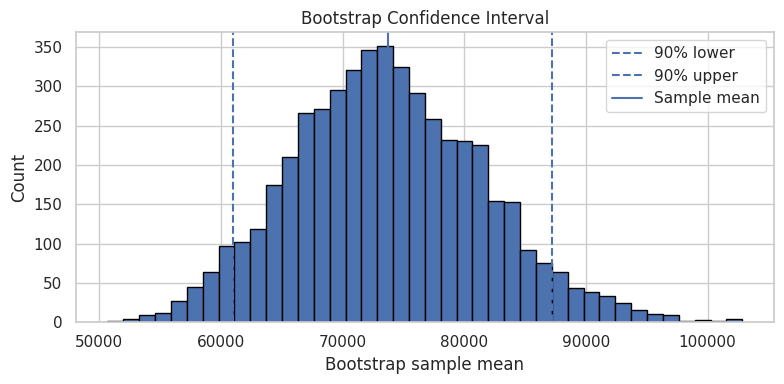

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(bootstrap_means, bins=40, edgecolor="black")
ax.axvline(ci_90[0], linestyle="--", label="90% lower")
ax.axvline(ci_90[1], linestyle="--", label="90% upper")
ax.axvline(sample_20.mean(), linestyle="-", label="Sample mean")
ax.set_xlabel("Bootstrap sample mean")
ax.set_ylabel("Count")
ax.set_title("Bootstrap Confidence Interval")
ax.legend()
plt.tight_layout()
plt.show()

# 10. Normal Distribution

Normal distribution adalah distribusi berbentuk bell curve yang ditentukan oleh mean dan standard deviation.

Untuk normal distribution:

- sekitar 68% data berada dalam ±1 standard deviation,
- sekitar 95% berada dalam ±2 standard deviations,
- sekitar 99.7% berada dalam ±3 standard deviations.

Namun, chapter menekankan bahwa **tidak semua data mengikuti distribusi normal**. Normal distribution sering penting karena sifat matematisnya dan hubungannya dengan sampling distributions.

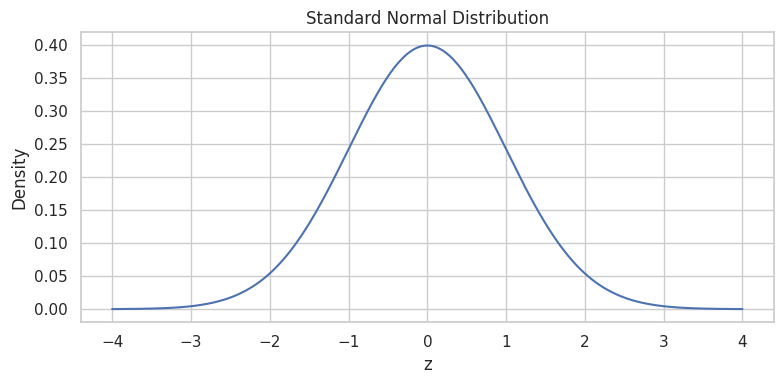

In [13]:
x = np.linspace(-4, 4, 500)
normal_pdf = stats.norm.pdf(x)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, normal_pdf)
ax.set_xlabel("z")
ax.set_ylabel("Density")
ax.set_title("Standard Normal Distribution")
plt.tight_layout()
plt.show()

# 11. Standard Normal, Z-score, dan QQ-Plot

Standardization mengubah suatu nilai menjadi z-score:

\[
z = \frac{x-\bar{x}}{s}
\]

QQ-plot digunakan untuk membandingkan quantile data dengan quantile distribusi teoritis, misalnya normal distribution.

Jika titik-titik mengikuti garis referensi secara cukup dekat, data lebih konsisten dengan distribusi yang diuji. Penyimpangan sistematis dari garis dapat menunjukkan skewness atau heavy tails.

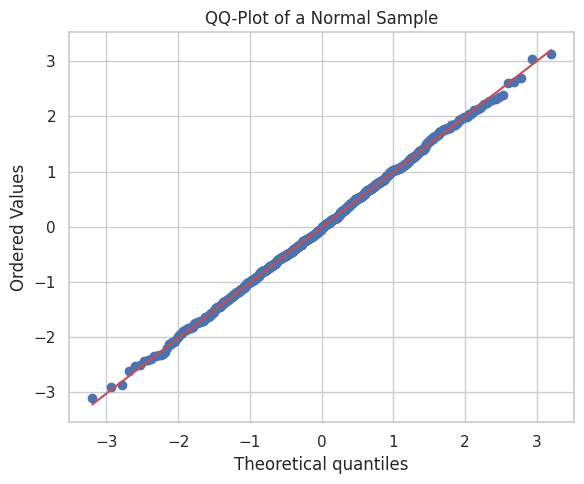

In [14]:
normal_sample = rng.normal(size=1000)

fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(normal_sample, dist="norm", plot=ax)
ax.set_title("QQ-Plot of a Normal Sample")
plt.tight_layout()
plt.show()

# 12. Long-Tailed Distributions

Distribusi long-tailed memiliki bagian ekor yang relatif panjang sehingga nilai ekstrem lebih sering terjadi daripada yang diperkirakan oleh normal distribution.

Chapter menggunakan return saham Netflix sebagai contoh. Data financial return dapat memiliki heavy tails, sehingga asumsi normal dapat meremehkan peluang extreme events.

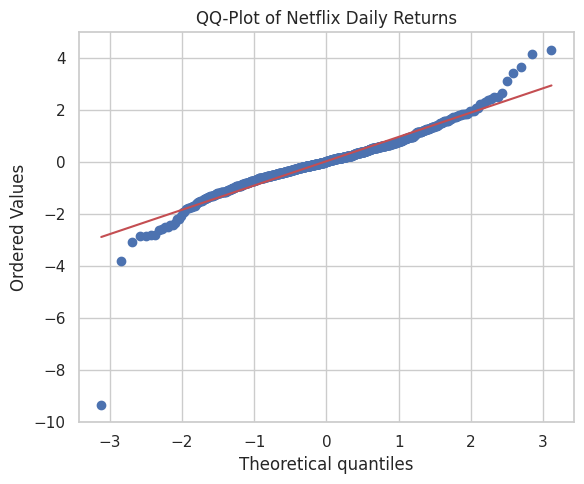

In [15]:
sp500_px = pd.read_csv(
    DATA_BASE + "sp500_data.csv.gz",
    index_col=0
)

nflx = sp500_px.loc[
    sp500_px.index >= "2012-07-01", "NFLX"
].dropna()

fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(nflx, dist="norm", plot=ax)
ax.set_title("QQ-Plot of Netflix Daily Returns")
plt.tight_layout()
plt.show()

### Interpretasi QQ-Plot

Jika data benar-benar normal, titik-titik akan relatif dekat dengan garis. Pada return Netflix, bagian ekor menyimpang dari garis normal, menunjukkan bahwa extreme returns lebih sering daripada yang diharapkan dari normal distribution.

Ini menunjukkan mengapa pemilihan distribusi perlu mempertimbangkan karakteristik data nyata.

# 13. Student's t-Distribution

Student's t-distribution memiliki bentuk yang mirip normal tetapi ekornya lebih tebal. Distribusi ini digunakan ketika melakukan inference terhadap mean terutama ketika sample relatif kecil dan standard deviation population tidak diketahui.

Parameter pentingnya adalah **degrees of freedom (df)**.

Ketika df semakin besar, t-distribution semakin mendekati normal distribution.

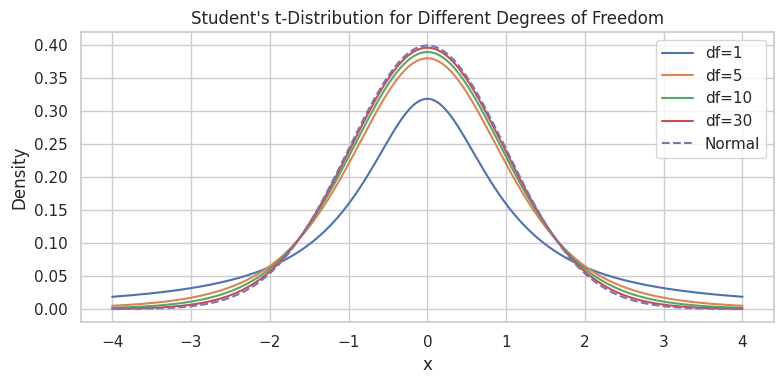

In [16]:
x = np.linspace(-4, 4, 500)

fig, ax = plt.subplots(figsize=(8, 4))

for df in [1, 5, 10, 30]:
    ax.plot(x, stats.t.pdf(x, df=df), label=f"df={df}")

ax.plot(x, stats.norm.pdf(x), linestyle="--", label="Normal")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_title("Student's t-Distribution for Different Degrees of Freedom")
ax.legend()
plt.tight_layout()
plt.show()

# 14. Binomial Distribution

Binomial distribution digunakan ketika terdapat sejumlah trial independen, setiap trial memiliki dua outcome, dan probabilitas success tetap \(p\).

Parameter:

- \(n\) = jumlah trial,
- \(p\) = probabilitas success,
- \(X\) = jumlah success.

Mean:

\[
E(X)=np
\]

Variance:

\[
Var(X)=np(1-p)
\]

Contoh: jumlah keberhasilan dalam 10 percobaan dengan probabilitas keberhasilan 0.1.

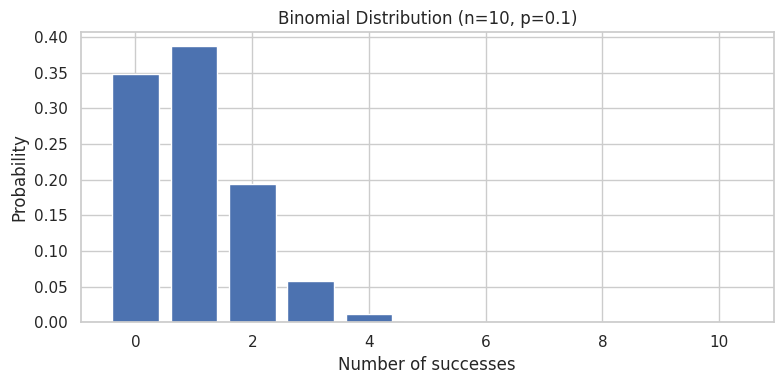

Mean     : 1.0
Variance : 0.9
P(X=2)   : 0.19371024450000007


In [17]:
n = 10
p = 0.1
x = np.arange(0, n + 1)

pmf = stats.binom.pmf(x, n, p)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x, pmf)
ax.set_xlabel("Number of successes")
ax.set_ylabel("Probability")
ax.set_title(f"Binomial Distribution (n={n}, p={p})")
plt.tight_layout()
plt.show()

print("Mean     :", n * p)
print("Variance :", n * p * (1 - p))
print("P(X=2)   :", stats.binom.pmf(2, n, p))

# 15. Chi-Square Distribution

Chi-square distribution banyak digunakan pada data berupa **counts** dan muncul dalam berbagai prosedur pengujian statistik.

Secara umum, chi-square statistic mengukur seberapa jauh observed counts dari expected counts.

Semakin besar departure dari expected values, semakin besar nilai chi-square statistic.

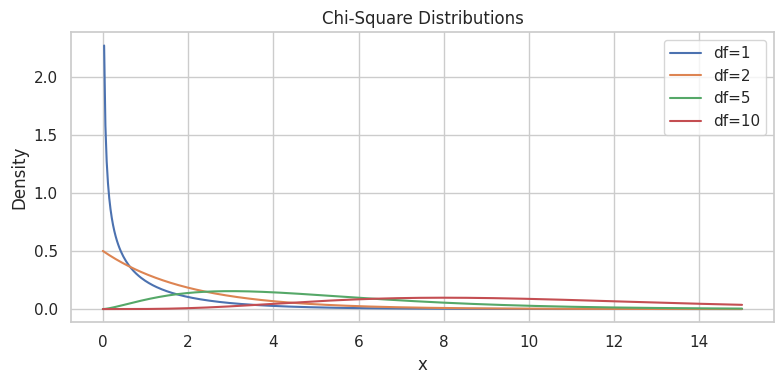

In [18]:
x = np.linspace(0, 15, 500)

fig, ax = plt.subplots(figsize=(8, 4))
for df in [1, 2, 5, 10]:
    ax.plot(x, stats.chi2.pdf(x, df=df), label=f"df={df}")

ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_title("Chi-Square Distributions")
ax.legend()
plt.tight_layout()
plt.show()

# 16. F-Distribution

F-distribution digunakan dalam konteks eksperimen dan linear models yang membandingkan variabilitas antar kelompok dengan variabilitas residual.

Salah satu penggunaan pentingnya adalah ANOVA.

F-statistic secara konseptual membandingkan variasi yang dijelaskan oleh perbedaan kelompok dengan variasi residual di dalam kelompok.

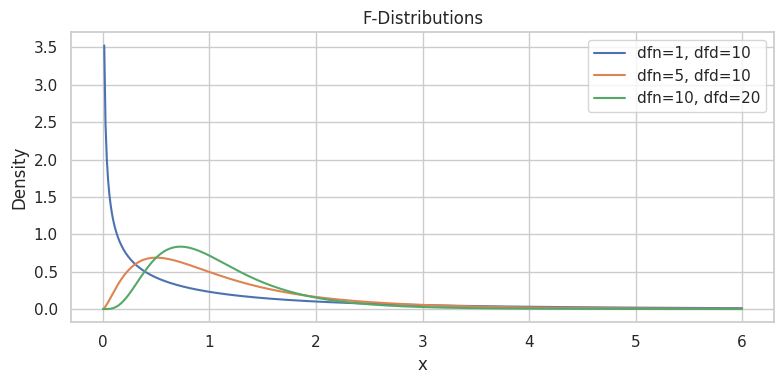

In [19]:
x = np.linspace(0, 6, 500)

fig, ax = plt.subplots(figsize=(8, 4))
for dfn, dfd in [(1, 10), (5, 10), (10, 20)]:
    ax.plot(
        x,
        stats.f.pdf(x, dfn, dfd),
        label=f"dfn={dfn}, dfd={dfd}"
    )

ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_title("F-Distributions")
ax.legend()
plt.tight_layout()
plt.show()

# 17. Poisson Distribution

Poisson distribution digunakan untuk memodelkan jumlah kejadian dalam interval waktu atau ruang ketika kejadian muncul secara acak dengan suatu rate \(\lambda\).

Parameter:

\[
\lambda = \text{rata-rata jumlah kejadian per unit waktu/ruang}
\]

Untuk Poisson:

\[
E(X)=\lambda
\]

\[
Var(X)=\lambda
\]

Contoh: jumlah customer calls per menit.

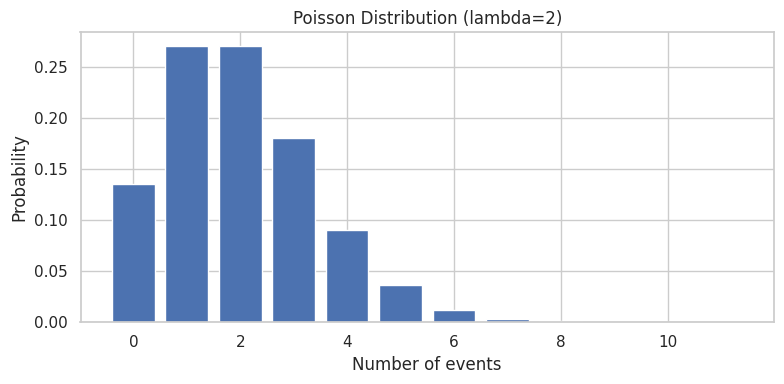

Mean     : 2
Variance : 2
P(X=3)   : 0.18044704431548356


In [20]:
lam = 2
x = np.arange(0, 12)

pmf = stats.poisson.pmf(x, mu=lam)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x, pmf)
ax.set_xlabel("Number of events")
ax.set_ylabel("Probability")
ax.set_title(f"Poisson Distribution (lambda={lam})")
plt.tight_layout()
plt.show()

print("Mean     :", lam)
print("Variance :", lam)
print("P(X=3)   :", stats.poisson.pmf(3, mu=lam))

# 18. Exponential Distribution

Exponential distribution memodelkan waktu atau jarak sampai terjadinya event berikutnya ketika event mengikuti proses Poisson dengan rate yang konstan.

Jika rate = \(\lambda\), maka mean waiting time adalah:

\[
E(X)=\frac{1}{\lambda}
\]

Hubungan ini membuat Poisson dan Exponential menjadi pasangan yang penting:

- Poisson → **berapa banyak event** dalam interval,
- Exponential → **berapa lama sampai event berikutnya**.

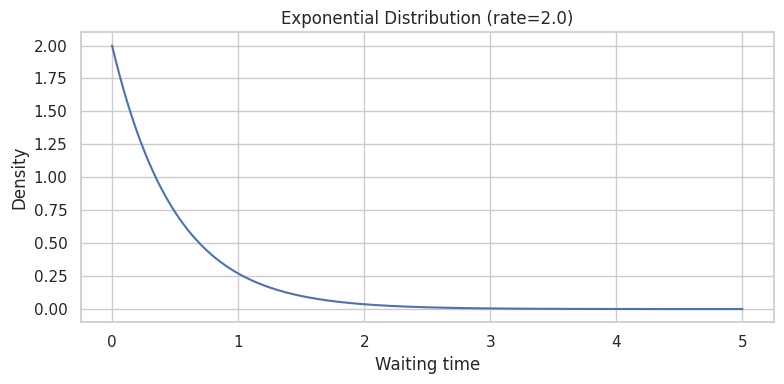

Expected waiting time: 0.5


In [21]:
rate = 2.0
x = np.linspace(0, 5, 500)

pdf = stats.expon.pdf(x, scale=1/rate)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, pdf)
ax.set_xlabel("Waiting time")
ax.set_ylabel("Density")
ax.set_title(f"Exponential Distribution (rate={rate})")
plt.tight_layout()
plt.show()

print("Expected waiting time:", 1 / rate)

# 19. Weibull Distribution

Weibull distribution merupakan generalisasi dari exponential distribution yang memungkinkan event rate berubah terhadap waktu.

Parameter yang penting:

- **shape** (\(\beta\)) — menentukan bagaimana hazard/event rate berubah,
- **scale** (\(\eta\)) — menentukan skala waktu.

Weibull banyak digunakan pada reliability dan time-to-failure analysis karena dapat menggambarkan failure rate yang meningkat, menurun, atau relatif konstan tergantung parameter.

/usr/local/lib/python3.13/dist-packages/scipy/stats/_continuous_distns.py:2750: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


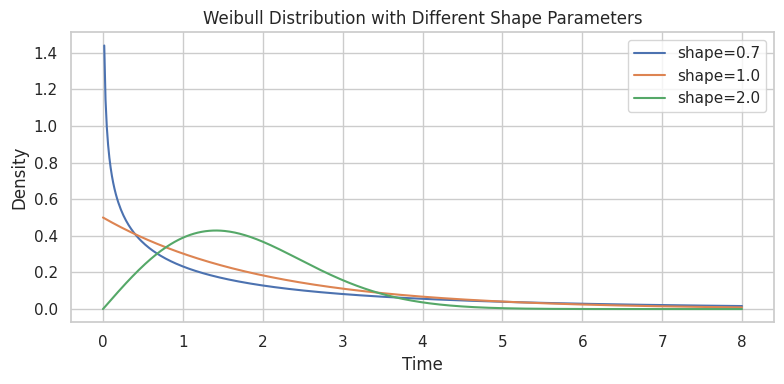

In [22]:
x = np.linspace(0, 8, 500)

fig, ax = plt.subplots(figsize=(8, 4))

for shape in [0.7, 1.0, 2.0]:
    ax.plot(
        x,
        stats.weibull_min.pdf(x, c=shape, scale=2),
        label=f"shape={shape}"
    )

ax.set_xlabel("Time")
ax.set_ylabel("Density")
ax.set_title("Weibull Distribution with Different Shape Parameters")
ax.legend()
plt.tight_layout()
plt.show()

# 20. Analisis dan Kesimpulan Chapter 2

Chapter 2 menunjukkan bahwa dalam statistical inference, masalah utama bukan hanya menghitung statistic, tetapi juga memahami **bagaimana statistic tersebut dapat berubah jika sample yang berbeda diambil**.

Beberapa kesimpulan penting:

1. **Big data tidak menghilangkan kebutuhan sampling.** Kualitas dan representativeness data tetap penting.
2. **Sample besar tidak otomatis bebas bias.** Jika mekanisme pemilihannya bias, hasil tetap dapat menyesatkan.
3. **Sampling distribution berbeda dari data distribution.** Distribusi sample statistic dapat jauh lebih sempit daripada distribusi data individual.
4. **Central Limit Theorem** menjelaskan mengapa sample mean dapat mendekati normal ketika sample cukup besar.
5. **Standard error** mengukur ketidakpastian sampling dari suatu statistic dan mengecil ketika sample size meningkat.
6. **Bootstrap** memberikan pendekatan praktis untuk memperkirakan sampling distribution tanpa harus mengetahui population distribution secara eksplisit.
7. **Confidence interval** menggunakan sampling variability untuk memberikan rentang estimasi.
8. **Normal distribution tidak selalu cocok untuk data nyata.** QQ-plot membantu mengidentifikasi penyimpangan, termasuk heavy tails.
9. **t-distribution** penting ketika sample relatif kecil dan standard deviation population tidak diketahui.
10. Distribusi **binomial, chi-square, F, Poisson, exponential, dan Weibull** menyediakan model probabilistik untuk berbagai jenis data dan proses.
